## Image handling

in Dharani using `PyrTifAccessor`

In [1]:
import sys
sys.path.append('..')
from dharani_functions import DharaniHelper
from image_access import PyrTifAccessor
import os

instantiate helper object for specimen 2

In [2]:
helper = DharaniHelper(specimennum=2)

In [3]:
print(helper)

Dharani_Specimen_2, downsample=3


In [4]:
sectionlist = helper.get_section_numbers()

In [5]:
len(sectionlist)

536

If listing csv are available, load them

In [49]:
from csv_handling import load_csv

listing = {}
listingcsvname = f'../directory-listings/Dharani_Specimen_{helper._specimennum}.csv'
if os.path.exists(listingcsvname):
    listing = load_csv(listingcsvname)


Take an arbitrary number, and test if it is available in `sectionlist`

In [50]:
55 in sectionlist

True

In [51]:
55 in listing

True

In [52]:
listing[55]

RowType(section_number='55', image_url='data2d/specimen_2/Specimen_2_55.tif', image_format='tif', image_resolution_mpp='4', image_width='16000', image_height='16000', atlas_url='', atlas_format='', viewer_url='https://brainportal.humanbrain.in/code/2dviewer/annotation/public?data=1&region=-1&section=55&type=hd')

filter for annotated sections (atlas_url non-empty)

In [53]:
for secnum, row in listing.items():
    if secnum < 200: # to avoid flooding the output , print only if 200 < secnum < 400
        continue
    if secnum > 400:
        break
    if row.atlas_url != '':
        print(row)
    

RowType(section_number='208', image_url='data2d/specimen_2/Specimen_2_208.tif', image_format='tif', image_resolution_mpp='1', image_width='64000', image_height='64000', atlas_url='https://dharani-fetal-brain-atlas.s3.us-west-2.amazonaws.com/data2d/specimen_2/Specimen_2_208.json', atlas_format='geojson', viewer_url='https://brainportal.humanbrain.in/code/2dviewer/annotation/public?data=1&region=-1&section=208')
RowType(section_number='250', image_url='data2d/specimen_2/Specimen_2_250.tif', image_format='tif', image_resolution_mpp='1', image_width='64000', image_height='64000', atlas_url='https://dharani-fetal-brain-atlas.s3.us-west-2.amazonaws.com/data2d/specimen_2/Specimen_2_250.json', atlas_format='geojson', viewer_url='https://brainportal.humanbrain.in/code/2dviewer/annotation/public?data=1&region=-1&section=250')
RowType(section_number='256', image_url='data2d/specimen_2/Specimen_2_256.tif', image_format='tif', image_resolution_mpp='1', image_width='64000', image_height='64000', atl

pick a number from the above. call `get_imagedims` to inspect the remote tif file. This function does not load the whole file, but just enough to find the image dimensions at the highest resolution

In [54]:
helper.get_imagedims(373)

(64000, 64000)

Get the downloadable link. This function returns a http url and a s3 url

Note: this will be a big file

In [13]:
url = helper.get_zoomable_img_url(373)

In [14]:
url

('https://dharani-fetal-brain-atlas.s3.us-west-2.amazonaws.com/data2d/specimen_2/Specimen_2_373.tif',
 's3://dharani-fetal-brain-atlas/data2d/specimen_2/Specimen_2_373.tif')

Get Viewer url. This is the direct link to view the section in Dharani platform without downloading

In [15]:
helper.get_viewer_url(373)

'https://brainportal.humanbrain.in/code/2dviewer/annotation/public?data=1&region=-1&section=373'

Instantiate PyrTifAccessor using the s3 url (`url[1]`)

In [16]:
accessor = PyrTifAccessor(url[1])

The time taken is for reading parts of the large tif file, and collating information about the levels and pages available in it

In [17]:
info=accessor.get_info()

The tif file is a nested data structure indexed by 'series', 'levels', and 'pages'

In [18]:
num_series = len(info['series'])
print(num_series)

1


In [19]:
num_levels_s0 = len(info['series'][0]['levels'])
print(num_levels_s0)

6


In [20]:
num_pages_s0_l3 = len(info['series'][0]['levels'][3])
print(num_pages_s0_l3)

1


**Notes**

In Dharani dataset, the number of series is 1, levels is 4 or 6 depending on the available mpp, and pages is 1 in each level.

The mpp in each level go as 1,2,4,8,16,32 for sections which have 1mpp data - i.e., annotated sections (high-to-low res in each increasing level)

For non-annotated sections, the mpp in each level go as 4,8,16,32.

So to get a 32 mpp thumbnail, you would read the last level's page 0

In [21]:
from matplotlib import pyplot as plt

The info dict of series 0, level 0 , page 0 can be read as follows

In [22]:
info['series'][0]['levels'][0]['pages'][0]

{'imagewidth': 64000,
 'imageheight': 64000,
 'tilewidth': 2000,
 'tilelength': 2000,
 'dtype': dtype('uint8'),
 'compression': <COMPRESSION.JPEG: 7>,
 'samplesperpixel': 3,
 'tiles_per_row': 32,
 'tiles_per_column': 32}

In [23]:
# or equivalently, as 
accessor.get_info(seriesnum=0,levelnum=0,pagenum=0)

{'imagewidth': 64000,
 'imageheight': 64000,
 'tilewidth': 2000,
 'tilelength': 2000,
 'dtype': dtype('uint8'),
 'compression': <COMPRESSION.JPEG: 7>,
 'samplesperpixel': 3,
 'tiles_per_row': 32,
 'tiles_per_column': 32}

## Image array access

**Method 1**: Whole Page access - caution: don't call `get_page` for high-res (lower level values)

In [28]:
thumbnail = accessor.get_page(0,5,0) # last level is 5; 32mpp thumbnail

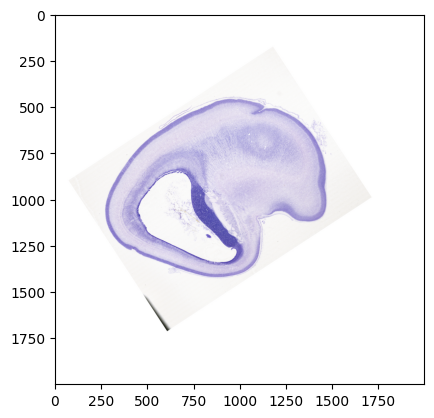

In [29]:
plt.imshow(thumbnail)

**Method 2**: `get_tile`. As the Dharani images are pyramidal tiled tif, we can read tiles by specifying tile_index. the info dict gives `tiles_per_row` and `tiles_per_column` which multiplied gives the number of tiles. Here is a sample from lev 3. First we get the lev3info, then display the tiling on thumbnail backdrop, then pick a tile_index, and call `get_tile`

In [27]:
from nb_functions import display_tiling_grid

In [30]:
lev3info = accessor.get_info(0,3,0)

Show the tiling for page3, with a backdrop of page5 (32 mpp thumbnail)

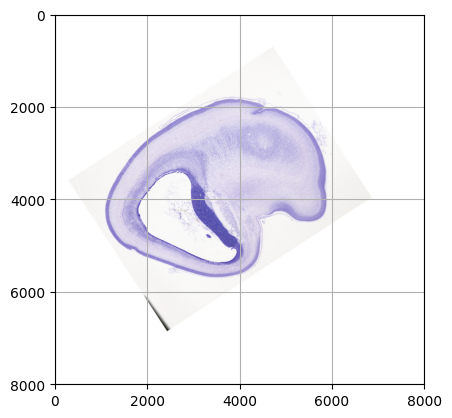

In [33]:
display_tiling_grid(thumbnail, lev3info)

Now get the tile 4 (second row's first tile)

In [34]:
lev3_tile4 = accessor.get_tile(0,3,0,4)

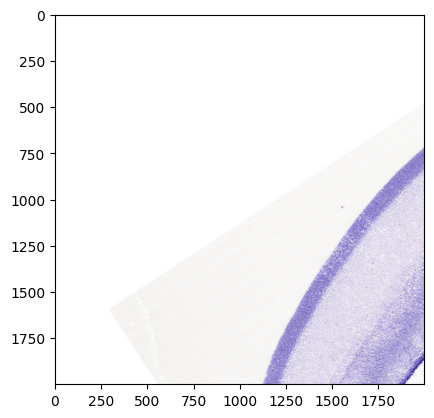

In [35]:
plt.imshow(lev3_tile4)

**Notes**

This is applicable for the level 0 (highest resolution) also..

Also, we provide a function `get_tiles`, that takes a list of `tile_index`, and outputs a dict: [tile_index: np_array_of_tile]

In [36]:
lev3_tiles = accessor.get_tiles(0,3,0,[4,5,8])

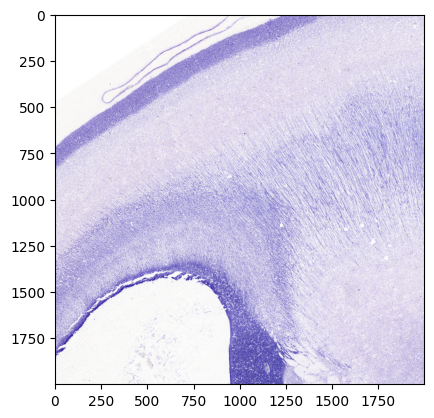

In [37]:
plt.imshow(lev3_tiles[5])

**Method 3**: `get_region` - this is for getting a region by passing whole page array indices left, top, width, height. This is useful to read regions that stride neighboring tiles

In [38]:
rgn = accessor.get_region(0,3,0,
                          1000, 3000, 1024,1024) # left, top, width, height

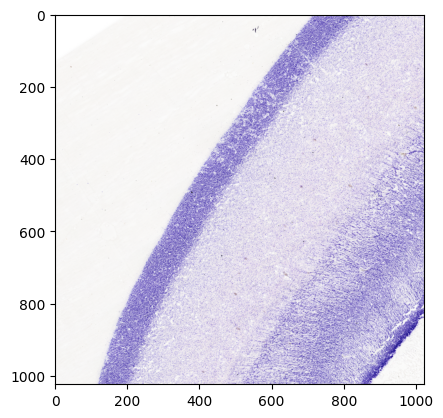

In [39]:
plt.imshow(rgn)

Finally, getting a high res tile

In [40]:
lev0info = accessor.get_info(0,0,0)

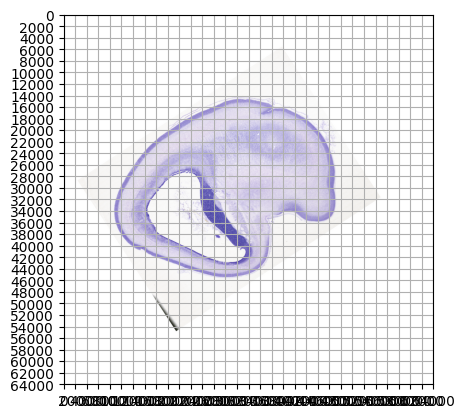

In [42]:
display_tiling_grid(thumbnail,lev0info)

In [43]:
lev0info

{'imagewidth': 64000,
 'imageheight': 64000,
 'tilewidth': 2000,
 'tilelength': 2000,
 'dtype': dtype('uint8'),
 'compression': <COMPRESSION.JPEG: 7>,
 'samplesperpixel': 3,
 'tiles_per_row': 32,
 'tiles_per_column': 32}

Select a tile index (sequential tile number in row major from top left)

In [44]:
row_sel = 28000//lev0info['tilelength']
col_sel = 5
tile_indx = row_sel*lev0info['tiles_per_row']+col_sel
print(tile_indx)

453


In [45]:
tile_highres = accessor.get_tile(0,0,0,453)

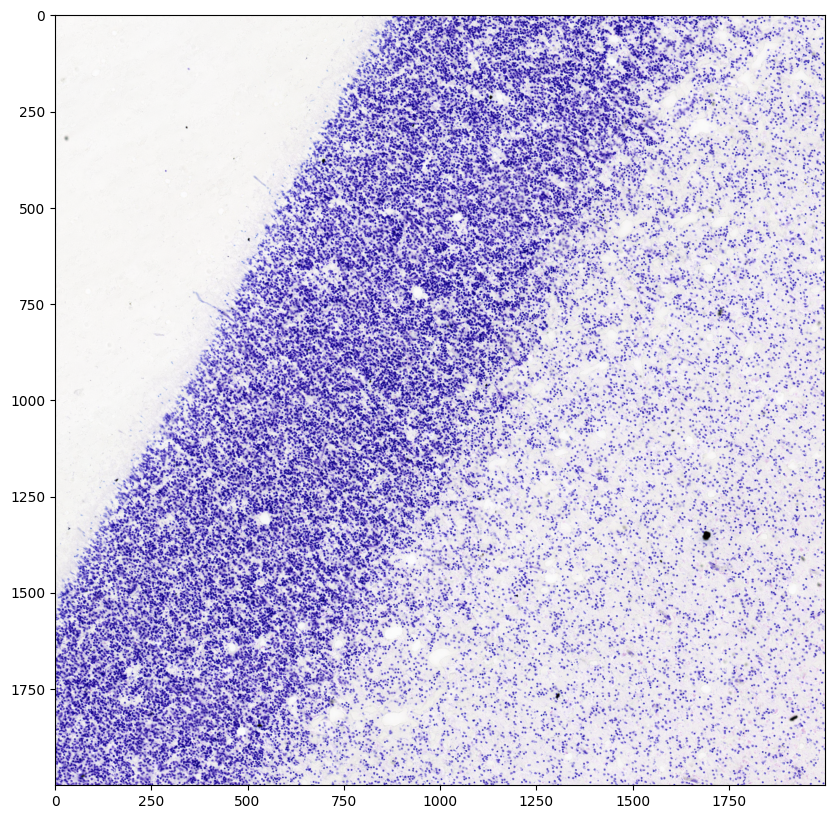

In [46]:
plt.figure(figsize=(10,10))
plt.imshow(tile_highres)